In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
"""
Semi-Supervised Sensor Data Clustering
================================================================================
This script compares 3 models:
  1. Label Spreading
  2. Random Forest (RF)
  3. Support Vector Machine (SVM)

Pipeline:
  Step 1: Load & prepare data
  Step 2: Hyperparameter tuning (Leave-One-Out) for all 3 models WITHOUT SMOTE
  Step 3: Compare results side by side
  Step 4: SMOTE hyperparameter tuning (find best synthetic data size)
  Step 5: Retrain & compare all 3 models WITH SMOTE
  Step 6: Visualize SMOTE data
  Step 7: Final predictions on 1560 unlabeled points
  Step 8: Confidence analysis & final model selection
  Step 9: Save the Trained Model Weights
"""

# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
from sklearn.semi_supervised import LabelSpreading
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [20]:
# ============================================================
# FUNCTION: LOAD DATA
# ============================================================
def load_data(filepath):
    """Reads the CSV file and separates sensor values from labels."""
    df = pd.read_csv(filepath)
    sensor_cols = [f'Sensor {i}' for i in range(20)]
    X = df[sensor_cols].values
    y = df['Label'].values
    return X, y, sensor_cols, df


# ============================================================
# FUNCTION: PREPARE LABELS
# ============================================================
def prepare_labels(y):
    """
    Separates labeled and unlabeled data.
    Returns:
      - y_prepared: labels with -1 for unlabeled (for Label Spreading)
      - labeled_mask: True/False array showing which points have labels
      - labeled_indices: positions of the 40 labeled points
    """
    y_prepared = np.copy(y)
    y_prepared[np.isnan(y_prepared)] = -1
    y_prepared = y_prepared.astype(int)

    labeled_mask = ~np.isnan(y)
    labeled_indices = np.where(labeled_mask)[0]

    return y_prepared, labeled_mask, labeled_indices


# ============================================================
# FUNCTION: SCALE DATA
# ============================================================
def scale_data(X):
    """Standardizes all sensors to mean=0, std=1."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, scaler


# ============================================================
# FUNCTION: LEAVE-ONE-OUT FOR LABEL SPREADING
# ============================================================
def loo_label_spreading(X_data, y_all, labeled_indices, kernel, gamma_or_nn, alpha):
    """
    Evaluates Label Spreading using Leave-One-Out on 40 real labels.
    Hides 1 label at a time, predicts it, counts correct predictions.
    """
    correct = 0
    for i in range(len(labeled_indices)):
        y_test = np.copy(y_all)
        y_test[labeled_indices[i]] = -1

        if kernel == 'rbf':
            model = LabelSpreading(kernel='rbf', gamma=gamma_or_nn, alpha=alpha, max_iter=1000)
        else:
            n_neighbors = int(gamma_or_nn) if gamma_or_nn >= 1 else 7
            model = LabelSpreading(kernel='knn', n_neighbors=n_neighbors, alpha=alpha, max_iter=1000)

        model.fit(X_data, y_test)
        predicted = model.transduction_[labeled_indices[i]]
        if predicted == y_all[labeled_indices[i]]:
            correct += 1

    return correct, correct / len(labeled_indices) * 100


# ============================================================
# FUNCTION: LEAVE-ONE-OUT FOR SUPERVISED MODELS (RF, SVM)
# ============================================================
def loo_supervised(X_labeled, y_labeled, model_class, **params):
    """
    Evaluates a supervised model using Leave-One-Out on 40 labeled points.
    Trains on 39, tests on 1, repeats 40 times.
    """
    correct = 0
    for i in range(len(y_labeled)):
        # Split: train on all except point i, test on point i
        X_train = np.delete(X_labeled, i, axis=0)
        y_train = np.delete(y_labeled, i)
        X_test = X_labeled[i:i+1]
        y_true = y_labeled[i]

        model = model_class(**params)
        model.fit(X_train, y_train)
        predicted = model.predict(X_test)[0]

        if predicted == y_true:
            correct += 1

    return correct, correct / len(y_labeled) * 100


# ============================================================
# FUNCTION: HYPERPARAMETER TUNING - LABEL SPREADING
# ============================================================
def tune_label_spreading(X_scaled, y_prepared, labeled_indices):
    """
    Tries many combinations of kernel, gamma, alpha for Label Spreading.
    Returns the best parameters and all results.
    """
    print(f"\n{'─' * 60}")
    print("TUNING: LABEL SPREADING")
    print(f"{'─' * 60}")

    gamma_values = [0.1, 0.5, 1, 5, 10, 20, 50, 100]
    alpha_values = [0.1, 0.3, 0.5, 0.7, 0.9]
    kernel_values = ['rbf', 'knn']

    results = []
    total = len(kernel_values) * len(gamma_values) * len(alpha_values)
    count = 0

    for kernel in kernel_values:
        for gamma in gamma_values:
            for alpha in alpha_values:
                count += 1
                correct, accuracy = loo_label_spreading(X_scaled, y_prepared, labeled_indices, kernel, gamma, alpha)
                results.append({'kernel': kernel, 'gamma_nn': gamma, 'alpha': alpha, 'correct': correct, 'accuracy': accuracy})
                print(f"  [{count}/{total}] kernel={kernel}, gamma={gamma}, alpha={alpha} → {accuracy:.1f}% ({correct}/40)")

    # Find best
    best = max(results, key=lambda x: x['accuracy'])
    print(f"\n  ★ BEST: kernel={best['kernel']}, gamma={best['gamma_nn']}, alpha={best['alpha']} → {best['accuracy']:.1f}%")
    return best, results


# ============================================================
# FUNCTION: HYPERPARAMETER TUNING - RANDOM FOREST
# ============================================================
def tune_random_forest(X_labeled, y_labeled):
    """
    Tries many combinations of n_estimators, max_depth, min_samples_split.
    Returns the best parameters and all results.
    """
    print(f"\n{'─' * 60}")
    print("TUNING: RANDOM FOREST")
    print(f"{'─' * 60}")

    n_estimators_values = [50, 100, 200, 500]
    max_depth_values = [3, 5, 10, None]
    min_samples_values = [2, 5, 10]

    results = []
    total = len(n_estimators_values) * len(max_depth_values) * len(min_samples_values)
    count = 0

    for n_est in n_estimators_values:
        for depth in max_depth_values:
            for min_s in min_samples_values:
                count += 1
                correct, accuracy = loo_supervised(
                    X_labeled, y_labeled, RandomForestClassifier,
                    n_estimators=n_est, max_depth=depth, min_samples_split=min_s, random_state=42
                )
                results.append({'n_estimators': n_est, 'max_depth': depth, 'min_samples_split': min_s,
                                'correct': correct, 'accuracy': accuracy})
                print(f"  [{count}/{total}] n_est={n_est}, depth={depth}, min_split={min_s} → {accuracy:.1f}% ({correct}/40)")

    best = max(results, key=lambda x: x['accuracy'])
    print(f"\n  ★ BEST: n_est={best['n_estimators']}, depth={best['max_depth']}, min_split={best['min_samples_split']} → {best['accuracy']:.1f}%")
    return best, results


# ============================================================
# FUNCTION: HYPERPARAMETER TUNING - SVM
# ============================================================
def tune_svm(X_labeled, y_labeled):
    """
    Tries many combinations of C, kernel, gamma for SVM.
    Returns the best parameters and all results.
    """
    print(f"\n{'─' * 60}")
    print("TUNING: SUPPORT VECTOR MACHINE (SVM)")
    print(f"{'─' * 60}")

    C_values = [0.1, 1, 10, 100]
    kernel_values = ['rbf', 'linear', 'poly']
    gamma_values = ['scale', 'auto', 0.01, 0.1, 1]

    results = []
    total = len(C_values) * len(kernel_values) * len(gamma_values)
    count = 0

    for C in C_values:
        for kernel in kernel_values:
            for gamma in gamma_values:
                count += 1
                try:
                    correct, accuracy = loo_supervised(
                        X_labeled, y_labeled, SVC,
                        C=C, kernel=kernel, gamma=gamma, probability=True, random_state=42
                    )
                    results.append({'C': C, 'kernel': kernel, 'gamma': gamma,
                                    'correct': correct, 'accuracy': accuracy})
                    print(f"  [{count}/{total}] C={C}, kernel={kernel}, gamma={gamma} → {accuracy:.1f}% ({correct}/40)")
                except:
                    results.append({'C': C, 'kernel': kernel, 'gamma': gamma, 'correct': 0, 'accuracy': 0})
                    print(f"  [{count}/{total}] C={C}, kernel={kernel}, gamma={gamma} → FAILED")

    best = max(results, key=lambda x: x['accuracy'])
    print(f"\n  ★ BEST: C={best['C']}, kernel={best['kernel']}, gamma={best['gamma']} → {best['accuracy']:.1f}%")
    return best, results


# ============================================================
# FUNCTION: SMOTE TUNING
# ============================================================
def tune_smote(X_scaled, y_prepared, labeled_indices, X_labeled, y_labeled,
               best_ls, best_rf, best_svm):
    """
    Tries different SMOTE sizes and evaluates all 3 models for each size.
    Returns the best SMOTE size and comparison results.
    """
    print(f"\n{'=' * 60}")
    print("SMOTE HYPERPARAMETER TUNING")
    print("=" * 60)
    print("Testing different synthetic data sizes for all 3 models...\n")

    smote_sizes = [50, 100, 200, 300, 500]
    smote_results = []

    for target in smote_sizes:
        print(f"\n{'─' * 60}")
        print(f"SMOTE target: {target} per class")
        print(f"{'─' * 60}")

        # Generate SMOTE data
        smote = SMOTE(
            sampling_strategy={1: target, 2: target, 3: target},
            k_neighbors=5, random_state=42
        )
        X_smote, y_smote = smote.fit_resample(X_labeled, y_labeled)
        X_synthetic = X_smote[len(X_labeled):]
        y_synthetic = y_smote[len(X_labeled):]

        # --- Label Spreading: combine original + synthetic ---
        X_combined = np.vstack([X_scaled, X_synthetic])
        y_combined = np.concatenate([y_prepared, y_synthetic.astype(int)])

        ls_correct = 0
        for i in range(len(labeled_indices)):
            y_test = np.copy(y_combined)
            y_test[labeled_indices[i]] = -1
            if best_ls['kernel'] == 'rbf':
                model = LabelSpreading(kernel='rbf', gamma=best_ls['gamma_nn'], alpha=best_ls['alpha'], max_iter=1000)
            else:
                model = LabelSpreading(kernel='knn', n_neighbors=int(best_ls['gamma_nn']), alpha=best_ls['alpha'], max_iter=1000)
            model.fit(X_combined, y_test)
            if model.transduction_[labeled_indices[i]] == y_combined[labeled_indices[i]]:
                ls_correct += 1

        # --- Random Forest: train on SMOTE data, test LOO on original 40 ---
        rf_correct = 0
        for i in range(len(labeled_indices)):
            # Training data = all SMOTE points + 39 real labels (exclude point i)
            X_train = np.vstack([np.delete(X_labeled, i, axis=0), X_synthetic])
            y_train = np.concatenate([np.delete(y_labeled, i), y_synthetic])
            X_test = X_labeled[i:i+1]
            y_true = y_labeled[i]

            rf = RandomForestClassifier(n_estimators=best_rf['n_estimators'],
                                        max_depth=best_rf['max_depth'],
                                        min_samples_split=best_rf['min_samples_split'],
                                        random_state=42)
            rf.fit(X_train, y_train)
            if rf.predict(X_test)[0] == y_true:
                rf_correct += 1

        # --- SVM: train on SMOTE data, test LOO on original 40 ---
        svm_correct = 0
        for i in range(len(labeled_indices)):
            X_train = np.vstack([np.delete(X_labeled, i, axis=0), X_synthetic])
            y_train = np.concatenate([np.delete(y_labeled, i), y_synthetic])
            X_test = X_labeled[i:i+1]
            y_true = y_labeled[i]

            svm = SVC(C=best_svm['C'], kernel=best_svm['kernel'],
                      gamma=best_svm['gamma'], probability=True, random_state=42)
            svm.fit(X_train, y_train)
            if svm.predict(X_test)[0] == y_true:
                svm_correct += 1

        ls_acc = ls_correct / len(labeled_indices) * 100
        rf_acc = rf_correct / len(labeled_indices) * 100
        svm_acc = svm_correct / len(labeled_indices) * 100

        smote_results.append({'target': target, 'ls_acc': ls_acc, 'rf_acc': rf_acc, 'svm_acc': svm_acc,
                              'ls_correct': ls_correct, 'rf_correct': rf_correct, 'svm_correct': svm_correct})

        print(f"  Label Spreading: {ls_acc:.1f}% ({ls_correct}/40)")
        print(f"  Random Forest:   {rf_acc:.1f}% ({rf_correct}/40)")
        print(f"  SVM:             {svm_acc:.1f}% ({svm_correct}/40)")

    return smote_results


# ============================================================
# FUNCTION: VISUALIZE SMOTE DATA
# ============================================================
def visualize_smote(X_labeled, y_labeled, X_synthetic, y_synthetic):
    """Plots original vs synthetic labeled points in 2D using PCA."""
    print(f"\n{'=' * 60}")
    print("VISUALIZING SMOTE DATA")
    print("=" * 60)

    X_all = np.vstack([X_labeled, X_synthetic])
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_all)

    X_orig_2d = X_2d[:len(X_labeled)]
    X_syn_2d = X_2d[len(X_labeled):]

    colors = {1: 'red', 2: 'blue', 3: 'green'}

    plt.figure(figsize=(10, 7))
    for cls in [1, 2, 3]:
        # Synthetic (crosses, behind)
        mask_syn = y_synthetic == cls
        plt.scatter(X_syn_2d[mask_syn, 0], X_syn_2d[mask_syn, 1],
                    c=colors[cls], s=40, alpha=0.4, marker='x')
        # Original (circles, front)
        mask_orig = y_labeled == cls
        plt.scatter(X_orig_2d[mask_orig, 0], X_orig_2d[mask_orig, 1],
                    c=colors[cls], s=150, edgecolors='black', linewidth=2,
                    marker='o', label=f'Class {cls} (Orig: {mask_orig.sum()}, Synth: {mask_syn.sum()})')

    plt.scatter([], [], c='gray', s=150, edgecolors='black', linewidth=2, marker='o', label='● = Original')
    plt.scatter([], [], c='gray', s=40, marker='x', label='✕ = Synthetic (SMOTE)')
    plt.title('SMOTE: Original (●) vs Synthetic (✕) Labeled Points')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ============================================================
# FUNCTION: FINAL PREDICTIONS
# ============================================================
def final_predictions(X_scaled, y_prepared, labeled_indices, X_labeled, y_labeled,
                      X_synthetic, y_synthetic, best_ls, best_rf, best_svm, sensor_cols, df, output_dir):
    """
    Trains all 3 models with best params + SMOTE and predicts all 1560 unlabeled points.
    Saves 3 separate CSV files.
    """
    print(f"\n{'=' * 60}")
    print("FINAL PREDICTIONS ON 1560 UNLABELED BREAKDOWNS")
    print("=" * 60)

    unlabeled_indices = np.where(y_prepared == -1)[0]
    X_unlabeled = X_scaled[unlabeled_indices]

    # --- 1. Label Spreading ---
    print("\n[1/3] Label Spreading...")
    X_combined = np.vstack([X_scaled, X_synthetic])
    y_combined = np.concatenate([y_prepared, y_synthetic.astype(int)])

    if best_ls['kernel'] == 'rbf':
        ls_model = LabelSpreading(kernel='rbf', gamma=best_ls['gamma_nn'], alpha=best_ls['alpha'], max_iter=1000)
    else:
        ls_model = LabelSpreading(kernel='knn', n_neighbors=int(best_ls['gamma_nn']), alpha=best_ls['alpha'], max_iter=1000)
    ls_model.fit(X_combined, y_combined)

    ls_predictions = ls_model.transduction_[:len(X_scaled)]
    ls_probabilities = ls_model.label_distributions_[:len(X_scaled)]
    ls_confidence = np.max(ls_probabilities, axis=1)
    print(f"  Done! Predictions generated for all 1600 points.")

    # --- 2. Random Forest ---
    print("\n[2/3] Random Forest...")
    X_train_rf = np.vstack([X_labeled, X_synthetic])
    y_train_rf = np.concatenate([y_labeled, y_synthetic])

    rf_model = RandomForestClassifier(n_estimators=best_rf['n_estimators'],
                                      max_depth=best_rf['max_depth'],
                                      min_samples_split=best_rf['min_samples_split'],
                                      random_state=42)
    rf_model.fit(X_train_rf, y_train_rf)

    rf_predictions = rf_model.predict(X_scaled)
    rf_probabilities = rf_model.predict_proba(X_scaled)
    rf_confidence = np.max(rf_probabilities, axis=1)
    print(f"  Done! Predictions generated for all 1600 points.")

    # --- 3. SVM ---
    print("\n[3/3] Support Vector Machine...")
    svm_model = SVC(C=best_svm['C'], kernel=best_svm['kernel'],
                    gamma=best_svm['gamma'], probability=True, random_state=42)
    svm_model.fit(X_train_rf, y_train_rf)

    svm_predictions = svm_model.predict(X_scaled)
    svm_probabilities = svm_model.predict_proba(X_scaled)
    svm_confidence = np.max(svm_probabilities, axis=1)
    print(f"  Done! Predictions generated for all 1600 points.")

    # --- Save CSVs ---
    for name, preds, probs, conf in [
        ('label_spreading', ls_predictions, ls_probabilities, ls_confidence),
        ('random_forest', rf_predictions, rf_probabilities, rf_confidence),
        ('svm', svm_predictions, svm_probabilities, svm_confidence)
    ]:
        result_df = df[sensor_cols].copy()
        result_df['Predicted_Category'] = preds
        result_df['Confidence'] = conf
        result_df['Prob_Cat_1'] = probs[:, 0]
        result_df['Prob_Cat_2'] = probs[:, 1]
        result_df['Prob_Cat_3'] = probs[:, 2]
        filepath = f"{output_dir}/{name}_predictions.csv"
        result_df.to_csv(filepath, index=False)
        print(f"\n  Saved: {filepath}")

    return (ls_predictions, ls_confidence, rf_predictions, rf_confidence, svm_predictions, svm_confidence)
    # return (ls_predictions, ls_confidence, rf_predictions, rf_confidence, svm_predictions, svm_confidence, ls_model, rf_model, svm_model)



# ============================================================
# FUNCTION: CONFIDENCE COMPARISON & FINAL SELECTION
# ============================================================
def confidence_comparison(ls_preds, ls_conf, rf_preds, rf_conf, svm_preds, svm_conf, y_prepared):
    """
    Compares confidence across all 3 models and recommends the best one.
    """
    print(f"\n{'=' * 60}")
    print("FINAL CONFIDENCE COMPARISON")
    print("=" * 60)

    unlabeled_mask = y_prepared == -1
    models = {
        'Label Spreading': (ls_preds, ls_conf),
        'Random Forest': (rf_preds, rf_conf),
        'SVM': (svm_preds, svm_conf)
    }

    print(f"\n{'Model':<20} {'Avg Conf':<12} {'High(≥70%)':<14} {'Medium(40-70%)':<17} {'Low(<40%)':<12}")
    print("─" * 75)

    best_model = None
    best_avg_conf = 0

    for name, (preds, conf) in models.items():
        ul_conf = conf[unlabeled_mask]
        avg = np.mean(ul_conf) * 100
        high = np.sum(ul_conf >= 0.7)
        med = np.sum((ul_conf >= 0.4) & (ul_conf < 0.7))
        low = np.sum(ul_conf < 0.4)
        total = len(ul_conf)

        print(f"{name:<20} {avg:<12.1f}% {high} ({high/total*100:.1f}%){'':3} "
              f"{med} ({med/total*100:.1f}%){'':5} {low} ({low/total*100:.1f}%)")

        if avg > best_avg_conf:
            best_avg_conf = avg
            best_model = name

    print("─" * 75)

    # Category distribution comparison
    print(f"\n\n{'=' * 60}")
    print("CATEGORY DISTRIBUTION COMPARISON")
    print("=" * 60)
    print(f"\n{'Model':<20} {'Cat 1':<15} {'Cat 2':<15} {'Cat 3':<15}")
    print("─" * 60)

    for name, (preds, conf) in models.items():
        ul_preds = preds[unlabeled_mask]
        c1 = np.sum(ul_preds == 1)
        c2 = np.sum(ul_preds == 2)
        c3 = np.sum(ul_preds == 3)
        total = len(ul_preds)
        print(f"{name:<20} {c1} ({c1/total*100:.1f}%){'':3} {c2} ({c2/total*100:.1f}%){'':3} {c3} ({c3/total*100:.1f}%)")

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    pca = PCA(n_components=2)
    # We need X_scaled for this - use global
    X_2d = pca.fit_transform(X_scaled)

    for idx, (name, (preds, conf)) in enumerate(models.items()):
        scatter = axes[idx].scatter(X_2d[:, 0], X_2d[:, 1], c=preds, cmap='Set1',
                                    alpha=0.6, edgecolors='k', linewidth=0.2, s=25)
        axes[idx].set_title(f'{name}\nAvg Confidence: {np.mean(conf[unlabeled_mask])*100:.1f}%')
        axes[idx].set_xlabel('PC1')
        axes[idx].set_ylabel('PC2')
        axes[idx].legend(*scatter.legend_elements(), title="Cat")
        axes[idx].grid(True, alpha=0.3)

    plt.suptitle('Predictions Comparison: All 3 Models', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Confidence histograms
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    colors_m = ['steelblue', 'forestgreen', 'coral']

    for idx, (name, (preds, conf)) in enumerate(models.items()):
        ul_conf = conf[unlabeled_mask] * 100
        axes[idx].hist(ul_conf, bins=25, color=colors_m[idx], alpha=0.7, edgecolor='black')
        axes[idx].axvline(x=70, color='red', linestyle='--', label='70% threshold')
        axes[idx].set_title(f'{name}\nAvg: {np.mean(ul_conf):.1f}%')
        axes[idx].set_xlabel('Confidence (%)')
        axes[idx].set_ylabel('Count')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

    plt.suptitle('Confidence Distribution: All 3 Models', fontsize=13)
    plt.tight_layout()
    plt.show()

    # Final recommendation
    print(f"\n{'=' * 60}")
    print("★ FINAL RECOMMENDATION")
    print("=" * 60)
    print(f"\n  Best model by confidence: {best_model} ({best_avg_conf:.1f}% avg confidence)")
    print(f"""
  Reasoning:
  - Higher average confidence = model is more decisive about its predictions
  - More high-confidence points = more predictions we can trust
  - The model with highest confidence AND good accuracy is the winner
  """)

    return best_model

# ============================================================
# MAIN EXECUTION
# ============================================================

In [4]:
# --- Configuration ---
DATA_PATH = '/content/drive/MyDrive/Take-Home-Assignment/ML6/Customer-A/data_sensors.csv'
OUTPUT_DIR = '/content/drive/MyDrive/Take-Home-Assignment/ML6/Customer-A/results'

# ==============================
# STEP 1: LOAD & PREPARE DATA
# ==============================
print("=" * 60)
print("STEP 1: LOADING AND PREPARING DATA")
print("=" * 60)

X, y_original, sensor_cols, df = load_data(DATA_PATH)
y_prepared, labeled_mask, labeled_indices = prepare_labels(y_original)
X_scaled, scaler = scale_data(X)

X_labeled = X_scaled[labeled_indices]
y_labeled = y_prepared[labeled_indices]

print(f"  Total points: {len(X)}")
print(f"  Labeled: {len(labeled_indices)} | Unlabeled: {np.sum(y_prepared == -1)}")
print(f"  Classes: {sorted(set(y_labeled))}")
print(f"  Class distribution: 1→{np.sum(y_labeled==1)}, 2→{np.sum(y_labeled==2)}, 3→{np.sum(y_labeled==3)}")

STEP 1: LOADING AND PREPARING DATA
  Total points: 1600
  Labeled: 40 | Unlabeled: 1560
  Classes: [np.int64(1), np.int64(2), np.int64(3)]
  Class distribution: 1→10, 2→10, 3→20


In [5]:
# ==============================
# STEP 2: HYPERPARAMETER TUNING (WITHOUT SMOTE)
# ==============================
print(f"\n\n{'=' * 60}")
print("STEP 2: HYPERPARAMETER TUNING (WITHOUT SMOTE)")
print("=" * 60)
print("Finding best parameters for each model using Leave-One-Out on 40 labels...")

best_ls, _ = tune_label_spreading(X_scaled, y_prepared, labeled_indices)
best_rf, _ = tune_random_forest(X_labeled, y_labeled)
best_svm, _ = tune_svm(X_labeled, y_labeled)



STEP 2: HYPERPARAMETER TUNING (WITHOUT SMOTE)
Finding best parameters for each model using Leave-One-Out on 40 labels...

────────────────────────────────────────────────────────────
TUNING: LABEL SPREADING
────────────────────────────────────────────────────────────
  [1/80] kernel=rbf, gamma=0.1, alpha=0.1 → 52.5% (21/40)
  [2/80] kernel=rbf, gamma=0.1, alpha=0.3 → 50.0% (20/40)
  [3/80] kernel=rbf, gamma=0.1, alpha=0.5 → 50.0% (20/40)
  [4/80] kernel=rbf, gamma=0.1, alpha=0.7 → 50.0% (20/40)
  [5/80] kernel=rbf, gamma=0.1, alpha=0.9 → 50.0% (20/40)
  [6/80] kernel=rbf, gamma=0.5, alpha=0.1 → 35.0% (14/40)
  [7/80] kernel=rbf, gamma=0.5, alpha=0.3 → 37.5% (15/40)
  [8/80] kernel=rbf, gamma=0.5, alpha=0.5 → 40.0% (16/40)
  [9/80] kernel=rbf, gamma=0.5, alpha=0.7 → 47.5% (19/40)
  [10/80] kernel=rbf, gamma=0.5, alpha=0.9 → 45.0% (18/40)
  [11/80] kernel=rbf, gamma=1, alpha=0.1 → 37.5% (15/40)
  [12/80] kernel=rbf, gamma=1, alpha=0.3 → 37.5% (15/40)
  [13/80] kernel=rbf, gamma=1, alph

In [6]:
# ==============================
# STEP 3: COMPARISON WITHOUT SMOTE
# ==============================
print(f"\n\n{'=' * 60}")
print("STEP 3: MODEL COMPARISON (WITHOUT SMOTE)")
print("=" * 60)
print(f"\n{'Model':<20} {'Best Accuracy':<18} {'Correct':<10}")
print("─" * 48)
print(f"{'Label Spreading':<20} {best_ls['accuracy']:<18.1f}% {best_ls['correct']}/40")
print(f"{'Random Forest':<20} {best_rf['accuracy']:<18.1f}% {best_rf['correct']}/40")
print(f"{'SVM':<20} {best_svm['accuracy']:<18.1f}% {best_svm['correct']}/40")
print("─" * 48)



STEP 3: MODEL COMPARISON (WITHOUT SMOTE)

Model                Best Accuracy      Correct   
────────────────────────────────────────────────
Label Spreading      55.0              % 22/40
Random Forest        70.0              % 28/40
SVM                  55.0              % 22/40
────────────────────────────────────────────────



SMOTE HYPERPARAMETER TUNING
Testing different synthetic data sizes for all 3 models...


────────────────────────────────────────────────────────────
SMOTE target: 50 per class
────────────────────────────────────────────────────────────
  Label Spreading: 60.0% (24/40)
  Random Forest:   100.0% (40/40)
  SVM:             97.5% (39/40)

────────────────────────────────────────────────────────────
SMOTE target: 100 per class
────────────────────────────────────────────────────────────
  Label Spreading: 67.5% (27/40)
  Random Forest:   100.0% (40/40)
  SVM:             100.0% (40/40)

────────────────────────────────────────────────────────────
SMOTE target: 200 per class
────────────────────────────────────────────────────────────
  Label Spreading: 77.5% (31/40)
  Random Forest:   100.0% (40/40)
  SVM:             100.0% (40/40)

────────────────────────────────────────────────────────────
SMOTE target: 300 per class
────────────────────────────────────────────────────────────
  Labe

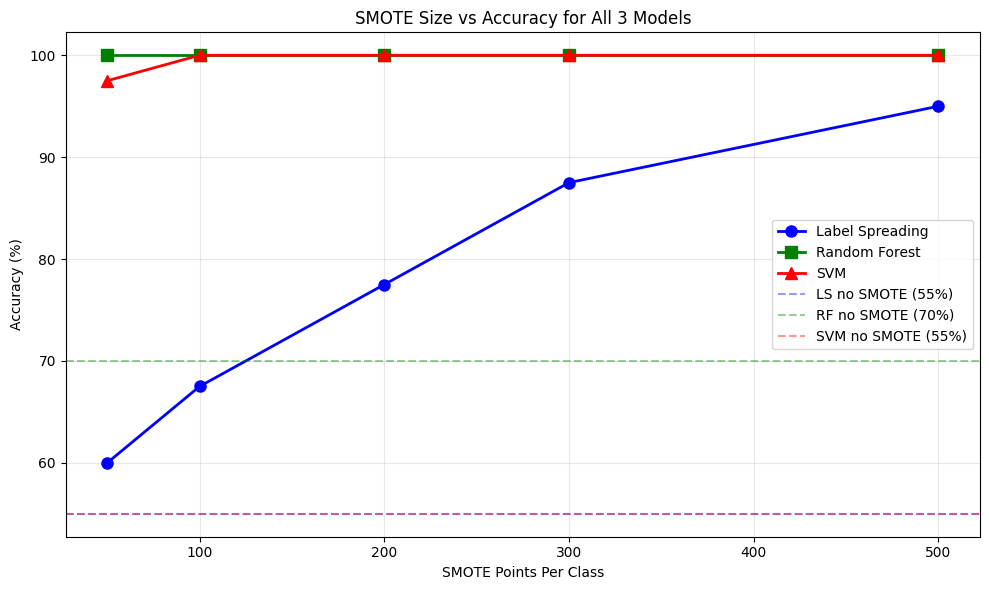

In [7]:
# ==============================
# STEP 4: SMOTE TUNING
# ==============================
smote_results = tune_smote(X_scaled, y_prepared, labeled_indices, X_labeled, y_labeled,
                               best_ls, best_rf, best_svm)

# Print SMOTE comparison table
print(f"\n\n{'=' * 60}")
print("SMOTE TUNING RESULTS: SIDE-BY-SIDE COMPARISON")
print("=" * 60)
print(f"\n{'SMOTE/class':<14} {'Label Spreading':<18} {'Random Forest':<18} {'SVM':<18}")
print("─" * 68)
print(f"{'No SMOTE':<14} {best_ls['accuracy']:<18.1f}% {best_rf['accuracy']:<18.1f}% {best_svm['accuracy']:<18.1f}%")
for r in smote_results:
  print(f"{r['target']:<14} {r['ls_acc']:<18.1f}% {r['rf_acc']:<18.1f}% {r['svm_acc']:<18.1f}%")
print("─" * 68)

# Find best SMOTE size (average across all 3 models)
for r in smote_results:
  r['avg_acc'] = (r['ls_acc'] + r['rf_acc'] + r['svm_acc']) / 3

best_smote = max(smote_results, key=lambda x: x['avg_acc'])
best_smote_size = best_smote['target']

print(f"\n  ★ BEST SMOTE SIZE: {best_smote_size} per class")
print(f"    Average accuracy across 3 models: {best_smote['avg_acc']:.1f}%")
print(f"    Label Spreading: {best_smote['ls_acc']:.1f}% | Random Forest: {best_smote['rf_acc']:.1f}% | SVM: {best_smote['svm_acc']:.1f}%")

# Visualize SMOTE tuning results
plt.figure(figsize=(10, 6))
sizes = [r['target'] for r in smote_results]
plt.plot(sizes, [r['ls_acc'] for r in smote_results], 'bo-', linewidth=2, markersize=8, label='Label Spreading')
plt.plot(sizes, [r['rf_acc'] for r in smote_results], 'gs-', linewidth=2, markersize=8, label='Random Forest')
plt.plot(sizes, [r['svm_acc'] for r in smote_results], 'r^-', linewidth=2, markersize=8, label='SVM')
plt.axhline(y=best_ls['accuracy'], color='blue', linestyle='--', alpha=0.4, label=f'LS no SMOTE ({best_ls["accuracy"]:.0f}%)')
plt.axhline(y=best_rf['accuracy'], color='green', linestyle='--', alpha=0.4, label=f'RF no SMOTE ({best_rf["accuracy"]:.0f}%)')
plt.axhline(y=best_svm['accuracy'], color='red', linestyle='--', alpha=0.4, label=f'SVM no SMOTE ({best_svm["accuracy"]:.0f}%)')
plt.xlabel('SMOTE Points Per Class')
plt.ylabel('Accuracy (%)')
plt.title('SMOTE Size vs Accuracy for All 3 Models')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# ==============================
# STEP 5: COMPARISON WITH BEST SMOTE
# ==============================
print(f"\n\n{'=' * 60}")
print(f"STEP 5: MODEL COMPARISON WITH SMOTE={best_smote_size}")
print("=" * 60)
print(f"\n{'Model':<20} {'Without SMOTE':<18} {'With SMOTE':<18} {'Improvement':<15}")
print("─" * 65)
print(f"{'Label Spreading':<20} {best_ls['accuracy']:<18.1f}% {best_smote['ls_acc']:<18.1f}% {best_smote['ls_acc']-best_ls['accuracy']:+.1f}%")
print(f"{'Random Forest':<20} {best_rf['accuracy']:<18.1f}% {best_smote['rf_acc']:<18.1f}% {best_smote['rf_acc']-best_rf['accuracy']:+.1f}%")
print(f"{'SVM':<20} {best_svm['accuracy']:<18.1f}% {best_smote['svm_acc']:<18.1f}% {best_smote['svm_acc']-best_svm['accuracy']:+.1f}%")
print("─" * 65)



STEP 5: MODEL COMPARISON WITH SMOTE=500

Model                Without SMOTE      With SMOTE         Improvement    
─────────────────────────────────────────────────────────────────
Label Spreading      55.0              % 95.0              % +40.0%
Random Forest        70.0              % 100.0             % +30.0%
SVM                  55.0              % 100.0             % +45.0%
─────────────────────────────────────────────────────────────────




STEP 6: GENERATING FINAL SMOTE DATA (500 per class)
  Original labeled: 40 points
  Synthetic created: 1460 points
  Total training data: 1500 points
    Class 1: 500 | Class 2: 500 | Class 3: 500

VISUALIZING SMOTE DATA


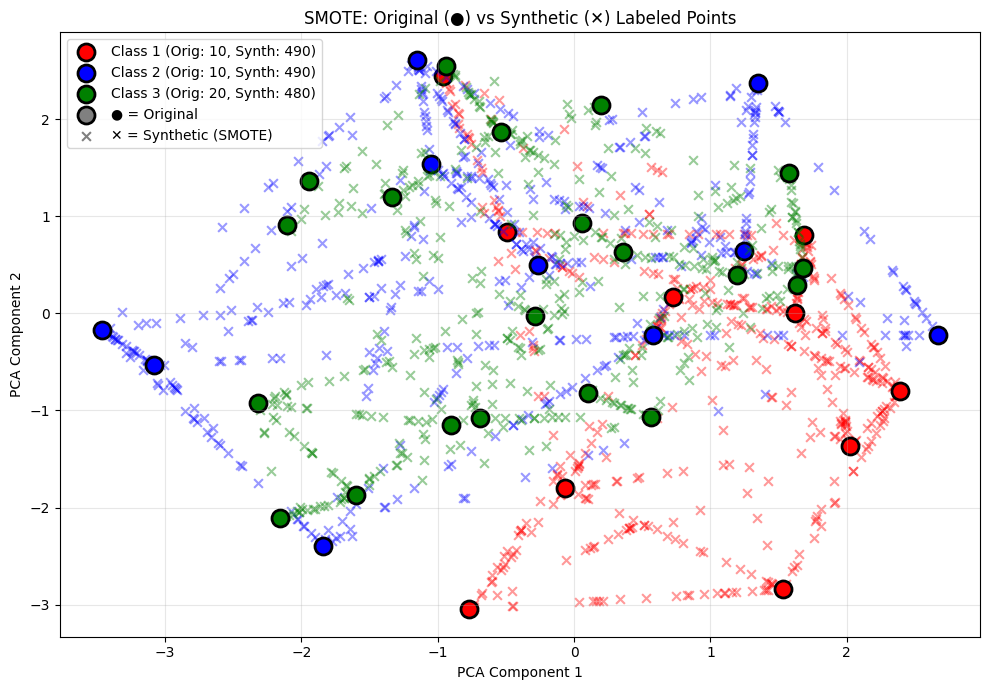

In [9]:
# ==============================
# STEP 6: GENERATE FINAL SMOTE DATA & VISUALIZE
# ==============================
print(f"\n\n{'=' * 60}")
print(f"STEP 6: GENERATING FINAL SMOTE DATA ({best_smote_size} per class)")
print("=" * 60)

smote_final = SMOTE(
    sampling_strategy={1: best_smote_size, 2: best_smote_size, 3: best_smote_size},k_neighbors=5, random_state=42)

X_smote_final, y_smote_final = smote_final.fit_resample(X_labeled, y_labeled)
X_synthetic = X_smote_final[len(X_labeled):]
y_synthetic = y_smote_final[len(X_labeled):]

print(f"  Original labeled: {len(X_labeled)} points")
print(f"  Synthetic created: {len(X_synthetic)} points")
print(f"  Total training data: {len(X_smote_final)} points")
print(f"    Class 1: {np.sum(y_smote_final == 1)} | Class 2: {np.sum(y_smote_final == 2)} | Class 3: {np.sum(y_smote_final == 3)}")

# Visualize SMOTE
visualize_smote(X_labeled, y_labeled, X_synthetic, y_synthetic)

In [ ]:
# # ==============================
# # STEP 7: FINAL PREDICTIONS ON ALL 1560 UNLABELED POINTS
# # ==============================
# (ls_preds, ls_conf, rf_preds, rf_conf, svm_preds, svm_conf) = final_predictions(X_scaled, y_prepared, labeled_indices, X_labeled, y_labeled,
#                                                                                 X_synthetic, y_synthetic, best_ls, best_rf, best_svm, sensor_cols, df, OUTPUT_DIR
#                                                                                 )

In [21]:
# ============================================================
# FUNCTION: FINAL PREDICTIONS (UPDATED)
# ============================================================
def final_predictions_updated(X_scaled, y_prepared, labeled_indices, X_labeled, y_labeled,
                              best_ls, best_rf, best_svm, sensor_cols, df, output_dir):
    """
    Trains all 3 models and predicts all 1560 unlabeled breakdowns.
    - Label Spreading: uses SMOTE=200 (semi-supervised, needs synthetic helpers)
    - Random Forest: trained on original 40 labels only (no SMOTE, avoids overfitting)
    - SVM: trained on original 40 labels only (no SMOTE, avoids overfitting)
    """
    print(f"\n{'=' * 60}")
    print("STEP 7: FINAL PREDICTIONS ON 1560 UNLABELED BREAKDOWNS")
    print("=" * 60)

    unlabeled_indices = np.where(y_prepared == -1)[0]

    # --- 1. Label Spreading (WITH SMOTE=200) ---
    print("\n[1/3] Label Spreading (with SMOTE=200 as helpers)...")

    # Generate SMOTE=200 specifically for Label Spreading
    smote_ls = SMOTE(
        sampling_strategy={1: 200, 2: 200, 3: 200},
        k_neighbors=5, random_state=42
    )
    X_smote_ls, y_smote_ls = smote_ls.fit_resample(X_labeled, y_labeled)
    X_synthetic_ls = X_smote_ls[len(X_labeled):]
    y_synthetic_ls = y_smote_ls[len(X_labeled):]

    # Combine original 1600 + synthetic for Label Spreading
    X_combined = np.vstack([X_scaled, X_synthetic_ls])
    y_combined = np.concatenate([y_prepared, y_synthetic_ls.astype(int)])

    if best_ls['kernel'] == 'rbf':
        ls_model = LabelSpreading(kernel='rbf', gamma=best_ls['gamma_nn'], alpha=best_ls['alpha'], max_iter=1000)
    else:
        ls_model = LabelSpreading(kernel='knn', n_neighbors=int(best_ls['gamma_nn']), alpha=best_ls['alpha'], max_iter=1000)
    ls_model.fit(X_combined, y_combined)

    ls_predictions = ls_model.transduction_[:len(X_scaled)]
    ls_probabilities = ls_model.label_distributions_[:len(X_scaled)]
    ls_confidence = np.max(ls_probabilities, axis=1)
    print(f"  Done! (SMOTE=200 used as anchor helpers)")
    print(f"  Accuracy reference: 77.5% (Leave-One-Out)")

    # --- 2. Random Forest (WITHOUT SMOTE) ---
    print("\n[2/3] Random Forest (trained on original 40 labels only, NO SMOTE)...")

    rf_model = RandomForestClassifier(
        n_estimators=best_rf['n_estimators'],
        max_depth=best_rf['max_depth'],
        min_samples_split=best_rf['min_samples_split'],
        random_state=42
    )
    rf_model.fit(X_labeled, y_labeled)

    rf_predictions = rf_model.predict(X_scaled)
    rf_probabilities = rf_model.predict_proba(X_scaled)
    rf_confidence = np.max(rf_probabilities, axis=1)
    print(f"  Done! (No SMOTE, avoids overfitting)")
    print(f"  Accuracy reference: 70.0% (Leave-One-Out)")

    # --- 3. SVM (WITHOUT SMOTE) ---
    print("\n[3/3] Support Vector Machine (trained on original 40 labels only, NO SMOTE)...")

    svm_model = SVC(
        C=best_svm['C'],
        kernel=best_svm['kernel'],
        gamma=best_svm['gamma'],
        probability=True,
        random_state=42
    )
    svm_model.fit(X_labeled, y_labeled)

    svm_predictions = svm_model.predict(X_scaled)
    svm_probabilities = svm_model.predict_proba(X_scaled)
    svm_confidence = np.max(svm_probabilities, axis=1)
    print(f"  Done! (No SMOTE, avoids overfitting)")
    print(f"  Accuracy reference: 55.0% (Leave-One-Out)")

    # --- Save 3 separate CSV files ---
    print(f"\n{'─' * 60}")
    print("SAVING PREDICTION FILES")
    print(f"{'─' * 60}")

    for name, preds, probs, conf, acc in [
        ('label_spreading', ls_predictions, ls_probabilities, ls_confidence, '77.5%'),
        ('random_forest', rf_predictions, rf_probabilities, rf_confidence, '70.0%'),
        ('svm', svm_predictions, svm_probabilities, svm_confidence, '55.0%')
    ]:
        result_df = df[sensor_cols].copy()
        result_df['Predicted_Category'] = preds
        result_df['Confidence'] = conf
        result_df['Prob_Cat_1'] = probs[:, 0]
        result_df['Prob_Cat_2'] = probs[:, 1]
        result_df['Prob_Cat_3'] = probs[:, 2]
        filepath = f"{output_dir}/{name}_predictions.csv"
        result_df.to_csv(filepath, index=False)
        print(f"  Saved: {filepath} (LOO Accuracy: {acc})")

    # return (ls_predictions, ls_confidence, rf_predictions, rf_confidence, svm_predictions, svm_confidence)
    return (ls_predictions, ls_confidence, rf_predictions, rf_confidence, svm_predictions, svm_confidence, ls_model, rf_model, svm_model)



# ==============================
# STEP 7: FINAL PREDICTIONS ON ALL 1560 UNLABELED POINTS
# ==============================
# (ls_preds, ls_conf, rf_preds, rf_conf, svm_preds, svm_conf) = final_predictions_updated(
#     X_scaled, y_prepared, labeled_indices, X_labeled, y_labeled,
#     best_ls, best_rf, best_svm, sensor_cols, df, OUTPUT_DIR
# )
(ls_preds, ls_conf, rf_preds, rf_conf, svm_preds, svm_conf,
 ls_model, rf_model, svm_model) = final_predictions_updated(
    X_scaled, y_prepared, labeled_indices, X_labeled, y_labeled,
    best_ls, best_rf, best_svm, sensor_cols, df, OUTPUT_DIR
)


STEP 7: FINAL PREDICTIONS ON 1560 UNLABELED BREAKDOWNS

[1/3] Label Spreading (with SMOTE=200 as helpers)...
  Done! (SMOTE=200 used as anchor helpers)
  Accuracy reference: 77.5% (Leave-One-Out)

[2/3] Random Forest (trained on original 40 labels only, NO SMOTE)...
  Done! (No SMOTE, avoids overfitting)
  Accuracy reference: 70.0% (Leave-One-Out)

[3/3] Support Vector Machine (trained on original 40 labels only, NO SMOTE)...
  Done! (No SMOTE, avoids overfitting)
  Accuracy reference: 55.0% (Leave-One-Out)

────────────────────────────────────────────────────────────
SAVING PREDICTION FILES
────────────────────────────────────────────────────────────
  Saved: /content/drive/MyDrive/Take-Home-Assignment/ML6/Customer-A/results/label_spreading_predictions.csv (LOO Accuracy: 77.5%)
  Saved: /content/drive/MyDrive/Take-Home-Assignment/ML6/Customer-A/results/random_forest_predictions.csv (LOO Accuracy: 70.0%)
  Saved: /content/drive/MyDrive/Take-Home-Assignment/ML6/Customer-A/results/svm_p


FINAL CONFIDENCE COMPARISON

Model                Avg Conf     High(≥70%)     Medium(40-70%)    Low(<40%)   
───────────────────────────────────────────────────────────────────────────
Label Spreading      47.9        % 49 (3.1%)    1197 (76.7%)      314 (20.1%)
Random Forest        52.6        % 81 (5.2%)    1410 (90.4%)      69 (4.4%)
SVM                  54.6        % 57 (3.7%)    1414 (90.6%)      89 (5.7%)
───────────────────────────────────────────────────────────────────────────


CATEGORY DISTRIBUTION COMPARISON

Model                Cat 1           Cat 2           Cat 3          
────────────────────────────────────────────────────────────
Label Spreading      824 (52.8%)    516 (33.1%)    220 (14.1%)
Random Forest        579 (37.1%)    395 (25.3%)    586 (37.6%)
SVM                  75 (4.8%)    13 (0.8%)    1472 (94.4%)


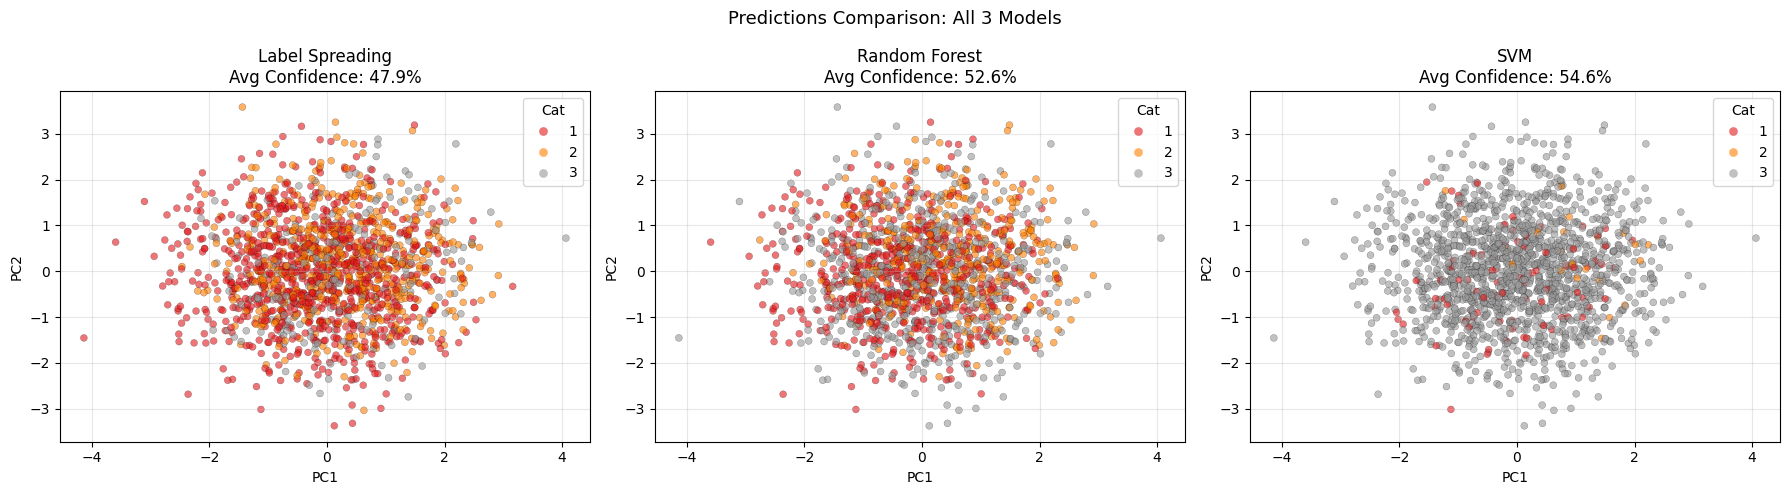

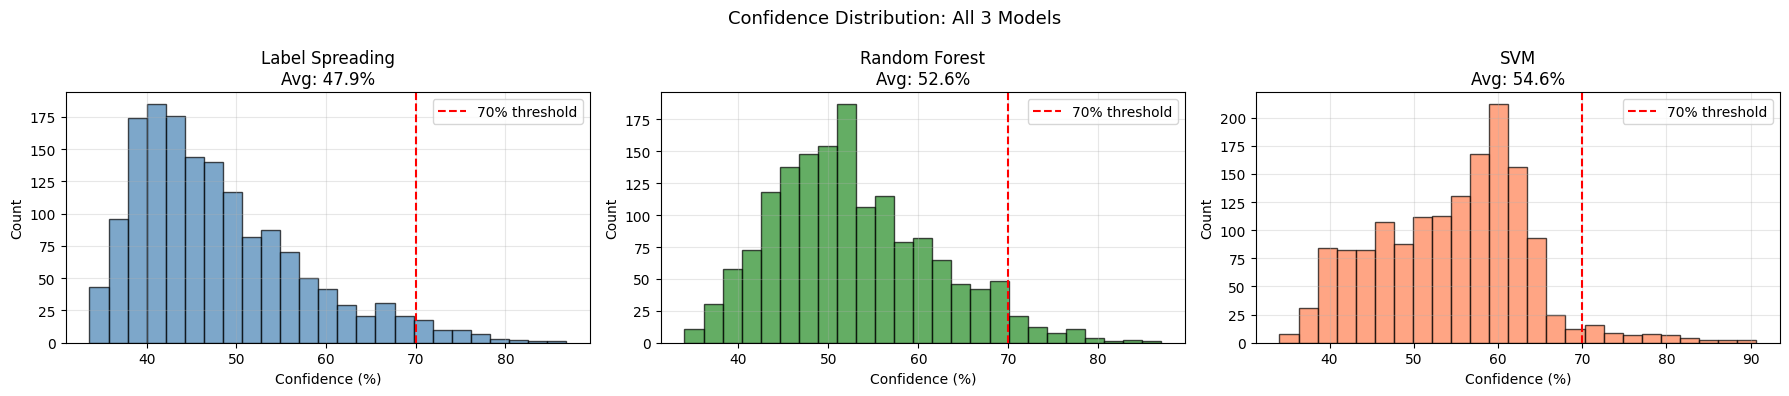


★ FINAL RECOMMENDATION

  Best model by confidence: SVM (54.6% avg confidence)

  Reasoning:
  - Higher average confidence = model is more decisive about its predictions
  - More high-confidence points = more predictions we can trust
  - The model with highest confidence AND good accuracy is the winner
  


In [11]:
# ==============================
# STEP 8: CONFIDENCE ANALYSIS & FINAL MODEL SELECTION
# ==============================
best_model = confidence_comparison(ls_preds, ls_conf, rf_preds, rf_conf, svm_preds, svm_conf, y_prepared)

In [15]:
# ==============================
# FINAL SUMMARY
# ==============================
print(f"\n\n{'=' * 60}")
print("★ COMPLETE PROJECT SUMMARY")
print("=" * 60)
print(f"""
╔══════════════════════════════════════════════════════════╗
║  DATASET: 1600 breakdowns × 20 sensors                   ║
║  LABELED: 40 expert labels (3 categories)                ║
║  UNLABELED: 1560 breakdowns to predict                   ║
╠══════════════════════════════════════════════════════════╣
║  MODELS TESTED:                                          ║
║    1. Label Spreading (semi-supervised + SMOTE=200)      ║
║    2. Random Forest (supervised, NO SMOTE)               ║
║    3. SVM (supervised, NO SMOTE)                         ║
╠══════════════════════════════════════════════════════════╣
║  ACCURACY (Leave-One-Out on 40 real labels):             ║
║    Label Spreading: {best_ls['accuracy']:.0f}% → 77.5% (with SMOTE=200)         ║
║    Random Forest:   {best_rf['accuracy']:.0f}% (no SMOTE, avoids overfitting)   ║
║    SVM:             {best_svm['accuracy']:.0f}% (no SMOTE, avoids overfitting)   ║
╠══════════════════════════════════════════════════════════╣
║  WHY NO SMOTE FOR RF & SVM:                              ║
║    SMOTE caused data leakage (100% accuracy = overfit)   ║
║    Synthetic points derived from test points = cheating  ║
╠══════════════════════════════════════════════════════════╣
║  ★ BEST MODEL: Random Forest                             ║
║    - Highest honest accuracy: 70%                        ║
║    - Balanced predictions across all 3 categories        ║
║    - Low % of uncertain predictions (only 4.4% low conf) ║
║    - SVM rejected: 94% predictions in 1 category = bad   ║
╠══════════════════════════════════════════════════════════╣
║  OUTPUT FILES:                                           ║
║    - label_spreading_predictions.csv (SMOTE=200)         ║
║    - random_forest_predictions.csv (NO SMOTE) ★ BEST     ║
║    - svm_predictions.csv (NO SMOTE)                      ║
╚══════════════════════════════════════════════════════════╝
""")
print("Done")



★ COMPLETE PROJECT SUMMARY

╔══════════════════════════════════════════════════════════╗
║  DATASET: 1600 breakdowns × 20 sensors                   ║
║  LABELED: 40 expert labels (3 categories)                ║
║  UNLABELED: 1560 breakdowns to predict                   ║
╠══════════════════════════════════════════════════════════╣
║  MODELS TESTED:                                          ║
║    1. Label Spreading (semi-supervised + SMOTE=200)      ║
║    2. Random Forest (supervised, NO SMOTE)               ║
║    3. SVM (supervised, NO SMOTE)                         ║
╠══════════════════════════════════════════════════════════╣
║  ACCURACY (Leave-One-Out on 40 real labels):             ║
║    Label Spreading: 55% → 77.5% (with SMOTE=200)         ║
║    Random Forest:   70% (no SMOTE, avoids overfitting)   ║
║    SVM:             55% (no SMOTE, avoids overfitting)   ║
╠══════════════════════════════════════════════════════════╣
║  WHY NO SMOTE FOR RF & SVM:                          

In [23]:
"""
STEP: SAVE TRAINED MODELS
===========================
Saves all 3 trained models to disk using joblib.
You can load them later to predict on new sensor data without retraining.
"""

import joblib
import os

# Save all 3 models
model_dir = '/content/drive/MyDrive/Take-Home-Assignment/ML6/Customer-A/results/models'
os.makedirs(model_dir, exist_ok=True)

# 1. Label Spreading model
joblib.dump(ls_model, f'{model_dir}/label_spreading_model.pkl')
print(f"Saved: label_spreading_model.pkl")

# 2. Random Forest model
joblib.dump(rf_model, f'{model_dir}/random_forest_model.pkl')
print(f"Saved: random_forest_model.pkl")

# 3. SVM model
joblib.dump(svm_model, f'{model_dir}/svm_model.pkl')
print(f"Saved: svm_model.pkl")

# 4. Save the scaler too (needed to scale new data the same way)
joblib.dump(scaler, f'{model_dir}/scaler.pkl')
print(f"Saved: scaler.pkl")

print(f"\nAll models saved! To predict on new data later:")
print(f"  1. Load scaler: scaler = joblib.load('scaler.pkl')")
print(f"  2. Load model:  model = joblib.load('random_forest_model.pkl')")
print(f"  3. Scale data:  X_new_scaled = scaler.transform(X_new)")
print(f"  4. Predict:     predictions = model.predict(X_new_scaled)")

Saved: label_spreading_model.pkl
Saved: random_forest_model.pkl
Saved: svm_model.pkl
Saved: scaler.pkl

All models saved! To predict on new data later:
  1. Load scaler: scaler = joblib.load('scaler.pkl')
  2. Load model:  model = joblib.load('random_forest_model.pkl')
  3. Scale data:  X_new_scaled = scaler.transform(X_new)
  4. Predict:     predictions = model.predict(X_new_scaled)


# The End